In [2]:
from pathlib import Path
import sys
import os

%load_ext autoreload
%autoreload 2

dir = Path().resolve().parents[1]

if dir not in sys.path:
    sys.path.append(str(dir))

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
from nn import Unet1D, Returns, RMSELoss, EarlyStopping
from scripts import train, evaluate
from utils import log_transform
import torch
from torch.utils.data import DataLoader
import yfinance as yf
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt

In [4]:
ticker = "^GSPC"
start_interval = "2010-01-01"
end_interval = "2026-01-01"
interval = "1d"

raw_snp500 = torch.tensor(yf.Ticker(ticker).history(start=start_interval, end=end_interval, interval=interval)["Close"].to_numpy())

In [5]:
len(raw_snp500)

4024

In [6]:
split = math.ceil(len(raw_snp500) * 0.2)
val_split = len(raw_snp500) - split * 2
test_split = len(raw_snp500) - split
train_raw_snp500, val_raw_snp500, test_raw_snp500 = raw_snp500[:val_split], raw_snp500[val_split:test_split], raw_snp500[test_split:]

window_size = 256

train_data = Returns(
  raw_returns=train_raw_snp500,
  window_size=window_size,
  transform=log_transform,
  standard=True
)
val_data = Returns(
  raw_returns=val_raw_snp500,
  window_size=window_size,
  transform=log_transform,
  standard=True
)
test_data = Returns(
  raw_returns=test_raw_snp500,
  window_size=window_size,
  transform=log_transform,
  standard=True
)

len(train_data), len(val_data), len(test_data)

(2158, 549, 549)

In [7]:
train_dataloader = DataLoader(train_data, batch_size=32, shuffle=True, drop_last=True)
val_dataloader = DataLoader(val_data, batch_size=32, shuffle=True, drop_last=True)
test_dataloader = DataLoader(test_data, batch_size=32, shuffle=True, drop_last=True)

next(iter(train_dataloader)).size()

torch.Size([32, 1, 256])

In [8]:
len(train_dataloader.dataset)

2158

In [9]:
device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(42)
torch.cuda.manual_seed(42)
device

'cpu'

In [10]:
betas = torch.linspace(1e-4, 2e-2, 1000)
type(1 - betas)

torch.Tensor

In [11]:
encoder_in_channels = [1, 4, 8, 16]
encoder_out_channels = [4, 8, 16, 32]
decoder_in_channels = [32, 16, 8, 4]
decoder_out_channels = [16, 8, 4, 1]
attn_res = 16
n_res_block = 2
T = 1000
num_heads = 4
betas = torch.linspace(1e-4, 2e-2, T)
alpha_hats = torch.cumprod(
  input=1-betas,
  dim=0,
  dtype=torch.float32
)

model = Unet1D(
  attn_res=attn_res,
  n_res_block=n_res_block,
  encoder_in_channels=encoder_in_channels,
  encoder_out_channels=encoder_out_channels,
  decoder_in_channels=decoder_in_channels,
  decoder_out_channels=decoder_out_channels,
  T=T,
  num_heads=num_heads
)

In [12]:
dir = Path().resolve().parents[1]
save_path = dir / "models"


In [13]:
loss_fn = RMSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
  optimizer=optimizer,
  mode='min',
  factor=0.4,
  patience=2,
  threshold=1e-4
)

early_stop = EarlyStopping(
  model=model,
  save_path=save_path,
  patience=10,
  delta=0,
  file_name="model_256.pth",
  verbose=True
)

In [14]:
train_result = train(
  train_data=train_dataloader,
  val_data=val_dataloader,
  optimizer=optimizer,
  loss_fn=loss_fn,
  epochs=100,
  alpha_hats=alpha_hats,
  model=model,
  scheduler=scheduler,
  early_stopping=early_stop,
  device=device,
  T=T
)

  1%|          | 1/100 [00:09<15:04,  9.13s/it]

Epoch : 0 | train_loss : 1.03 | val_loss : 0.87
New best model found. Current loss: 0.8736775762894574
Current LR:  [0.001]


  2%|▏         | 2/100 [00:18<15:35,  9.55s/it]

Epoch : 1 | train_loss : 0.79 | val_loss : 0.62
New best model found. Current loss: 0.6175983933841481
Current LR:  [0.001]


  3%|▎         | 3/100 [00:30<17:07, 10.59s/it]

...

Epoch : 30 | train_loss : 0.53 | val_loss : 0.50
Current LR:  [1.0240000000000004e-05]


 32%|███▏      | 32/100 [06:38<09:30,  8.40s/it]

Epoch : 31 | train_loss : 0.53 | val_loss : 0.47
Current LR:  [4.096000000000002e-06]


 32%|███▏      | 32/100 [06:45<14:20, 12.66s/it]

Epoch : 32 | train_loss : 0.53 | val_loss : 0.48
Stopping early as no improvement has been observed
Best Loss 0.46880191915175495
Overwriting an existing model...
The best model has been saved
Early stopping at epoch : 32
Total training time: 405.15809869766235 seconds


In [15]:
test_result = evaluate(
  test_dataloader,
  loss_fn=loss_fn,
  model=model,
  alpha_hats=alpha_hats,
  T=T,
  device=device
)
test_result

0.5429425958324882

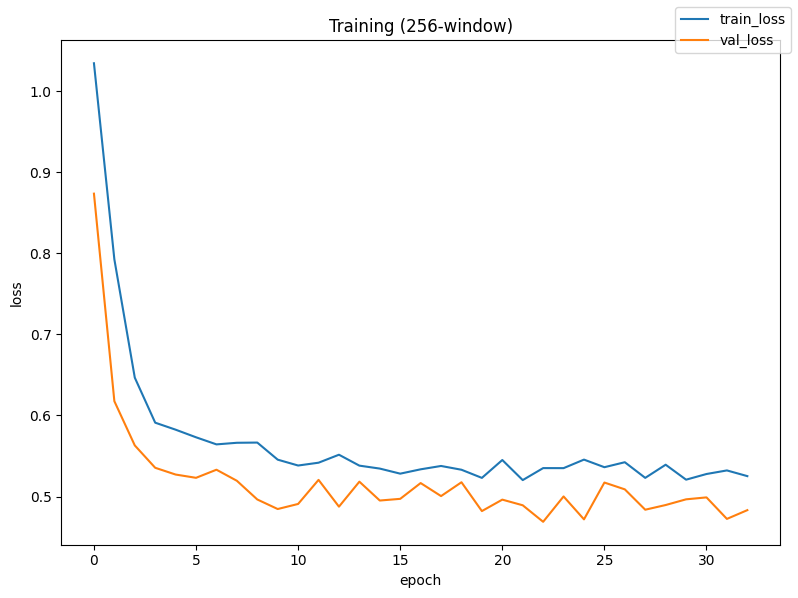

In [16]:
n_epochs = np.arange(0, len(train_result["train_loss"]))

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(n_epochs, train_result["train_loss"], label="train_loss")
ax.plot(n_epochs, train_result["val_loss"], label="val_loss")
# ax.set_xticks(n_epochs)

ax.set_title("Training (256-window)")
ax.set_ylabel("loss")
ax.set_xlabel("epoch")
fig.legend()

plt.tight_layout()
plt.show()